## Figure 4

The input files are available at [our repository on Zenodo](https://doi.org/10.5281/zenodo.19499423).

In [1]:
import os
import numpy as np
import pandas as pd

from PIL import Image
Image.MAX_IMAGE_PIXELS = 553190400

from statsmodels.stats.proportion import proportion_confint

from matplotlib import pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib import patches
import seaborn as sns
from matplotlib_venn import venn2

import SplIsoFind

/athena/tilgnerlab/scratch/lim4020/2022_08_15_PSIprediction/envs/SplIsoFind_016/lib/python3.9/site-packages/tqdm_joblib/__init__.py:4: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


### Read the results

In [2]:
dir_4k = 'stereoseq_data_analysis/S1_4K_ONT/isomatrix/res/MoransI_'
dir_comb = 'stereoseq_data_analysis/comb_AE_ONT/isomatrix/res_comb/MoransI_'
dir_S1 = 'stereoseq_data_analysis/comb_AE_ONT/isomatrix/res_S1/MoransI_'
dir_S2 = 'stereoseq_data_analysis/comb_AE_ONT/isomatrix/res_S2/MoransI_'

fn_end = '_nperm100000_k50_mincells250_mincellspergroup20_imb0.05_seed0.csv'

m_4k = pd.read_csv(f'{dir_4k}scores{fn_end}',
                   index_col=0)
p_4k = pd.read_csv(f'{dir_4k}pval{fn_end}',
                   index_col=0)
q_4k = pd.read_csv(f'{dir_4k}qval{fn_end}',
                   index_col=0)

m_comb = pd.read_csv(f'{dir_comb}scores{fn_end}',
                   index_col=0)
p_comb = pd.read_csv(f'{dir_comb}pval{fn_end}',
                   index_col=0)
q_comb = pd.read_csv(f'{dir_comb}qval{fn_end}',
                   index_col=0)

m_S1 = pd.read_csv(f'{dir_S1}scores{fn_end}',
                   index_col=0)
p_S1 = pd.read_csv(f'{dir_S1}pval{fn_end}',
                   index_col=0)
q_S1 = pd.read_csv(f'{dir_S1}qval{fn_end}',
                   index_col=0)

m_S2 = pd.read_csv(f'{dir_S2}scores{fn_end}',
                   index_col=0)
p_S2 = pd.read_csv(f'{dir_S2}pval{fn_end}',
                   index_col=0)
q_S2 = pd.read_csv(f'{dir_S2}qval{fn_end}',
                   index_col=0)

In [3]:
# Manually inflate adj p-value for isoforms with low morans I score
q_comb[m_comb < 0.01] = 1
q_S1[m_S1 < 0.01] = 1
q_S2[m_S2 < 0.01] = 1
q_4k[m_4k < 0.01] = 1

In [4]:
# Combine data per cell type
p_all = pd.concat((p_4k['All'], p_comb['All'], p_S1['All'], p_S2['All']),axis=1)
p_all.columns = ['S1 (4K)', 'S1+S2 (AllExome)', 'S1 (AllExome)', 'S2 (AllExome)']

q_all = pd.concat((q_4k['All'], q_comb['All'], q_S1['All'], q_S2['All']),axis=1)
q_all.columns = ['S1 (4K)', 'S1+S2 (AllExome)', 'S1 (AllExome)', 'S2 (AllExome)']

p_exc = pd.concat((p_4k['ExciteNeuron'], p_comb['ExciteNeuron'], p_S1['ExciteNeuron'], p_S2['ExciteNeuron']),axis=1)
p_exc.columns = ['S1 (4K)', 'S1+S2 (AllExome)', 'S1 (AllExome)', 'S2 (AllExome)']

q_exc = pd.concat((q_4k['ExciteNeuron'], q_comb['ExciteNeuron'], q_S1['ExciteNeuron'], q_S2['ExciteNeuron']),axis=1)
q_exc.columns = ['S1 (4K)', 'S1+S2 (AllExome)', 'S1 (AllExome)', 'S2 (AllExome)']

p_inh = pd.concat((p_4k['InhibNeuron'], p_comb['InhibNeuron'], p_S1['InhibNeuron'], p_S2['InhibNeuron']),axis=1)
p_inh.columns = ['S1 (4K)', 'S1+S2 (AllExome)', 'S1 (AllExome)', 'S2 (AllExome)']

q_inh = pd.concat((q_4k['InhibNeuron'], q_comb['InhibNeuron'], q_S1['InhibNeuron'], q_S2['InhibNeuron']),axis=1)
q_inh.columns = ['S1 (4K)', 'S1+S2 (AllExome)', 'S1 (AllExome)', 'S2 (AllExome)']

p_ast = pd.concat((p_4k['Astro'], p_comb['Astro'], p_S1['Astro'], p_S2['Astro']),axis=1)
p_ast.columns = ['S1 (4K)', 'S1+S2 (AllExome)', 'S1 (AllExome)', 'S2 (AllExome)']

q_ast = pd.concat((q_4k['Astro'], q_comb['Astro'], q_S1['Astro'], q_S2['Astro']),axis=1)
q_ast.columns = ['S1 (4K)', 'S1+S2 (AllExome)', 'S1 (AllExome)', 'S2 (AllExome)']

p_oli = pd.concat((p_4k['Oligo'], p_comb['Oligo'], p_S1['Oligo'], p_S2['Oligo']),axis=1)
p_oli.columns = ['S1 (4K)', 'S1+S2 (AllExome)', 'S1 (AllExome)', 'S2 (AllExome)']

q_oli = pd.concat((q_4k['Oligo'], q_comb['Oligo'], q_S1['Oligo'], q_S2['Oligo']),axis=1)
q_oli.columns = ['S1 (4K)', 'S1+S2 (AllExome)', 'S1 (AllExome)', 'S2 (AllExome)']


In [5]:
# Remove isoforms never tested
p_all = p_all[p_all.isna().all(axis=1) == False]
q_all = q_all[q_all.isna().all(axis=1) == False]

p_exc = p_exc[p_exc.isna().all(axis=1) == False]
q_exc = q_exc[q_exc.isna().all(axis=1) == False]

p_inh = p_inh[p_inh.isna().all(axis=1) == False]
q_inh = q_inh[q_inh.isna().all(axis=1) == False]

p_oli = p_oli[p_oli.isna().all(axis=1) == False]
q_oli = q_oli[q_oli.isna().all(axis=1) == False]

p_ast = p_ast[p_ast.isna().all(axis=1) == False]
q_ast = q_ast[q_ast.isna().all(axis=1) == False]



In [6]:
### Subset novel isoforms
q_all_novel = q_all.iloc[np.where(pd.DataFrame(q_all.index)['Transcript ID'].str.split('.', expand=True, n=3)[2].notna())[0]]
q_exc_novel = q_exc.iloc[np.where(pd.DataFrame(q_exc.index)['Transcript ID'].str.split('.', expand=True, n=3)[2].notna())[0]]
q_inh_novel = q_inh.iloc[np.where(pd.DataFrame(q_inh.index)['Transcript ID'].str.split('.', expand=True, n=3)[2].notna())[0]]
q_oli_novel = q_oli.iloc[np.where(pd.DataFrame(q_oli.index)['Transcript ID'].str.split('.', expand=True, n=3)[2].notna())[0]]
q_ast_novel = q_ast.iloc[np.where(pd.DataFrame(q_ast.index)['Transcript ID'].str.split('.', expand=True, n=3)[2].notna())[0]]


### Figure 4b - No. of SVI 

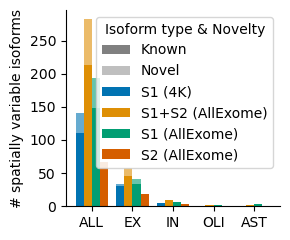

In [7]:
## Significant isoforms per dataset per celltype
sign_all = (q_all < 0.05).sum().reset_index()
sign_all['celltype'] = 'All'

sign_exc = (q_exc < 0.05).sum().reset_index()
sign_exc['celltype'] = 'Excite'

sign_inh = (q_inh < 0.05).sum().reset_index()
sign_inh['celltype'] = 'Inhib'

sign_oli = (q_oli < 0.05).sum().reset_index()
sign_oli['celltype'] = 'Oligo'

sign_ast = (q_ast < 0.05).sum().reset_index()
sign_ast['celltype'] = 'Astro'

sign_ct = pd.concat((sign_all, sign_exc, sign_inh, sign_oli, sign_ast),axis=0)

# Significant novel isoforms per dataset per celltype
sign_all_novel = (q_all_novel < 0.05).sum().reset_index()
sign_all_novel['celltype'] = 'All'

sign_exc_novel = (q_exc_novel < 0.05).sum().reset_index()
sign_exc_novel['celltype'] = 'Excite'

sign_inh_novel = (q_inh_novel < 0.05).sum().reset_index()
sign_inh_novel['celltype'] = 'Inhib'

sign_oli_novel = (q_oli_novel < 0.05).sum().reset_index()
sign_oli_novel['celltype'] = 'Oligo'

sign_ast_novel = (q_ast_novel < 0.05).sum().reset_index()
sign_ast_novel['celltype'] = 'Astro'

sign_ct_novel = pd.concat((sign_all_novel, sign_exc_novel, sign_inh_novel, sign_oli_novel, sign_ast_novel),axis=0)

# Merge the two
sign_ct_merged = sign_ct.merge(sign_ct_novel, on=['index', 'celltype'], suffixes=('_total', '_novel'))

celltypes = sign_ct_merged['celltype'].unique()
indices = sign_ct_merged['index'].unique()
x = np.arange(len(celltypes))
width = 0.2

palette = sns.color_palette('colorblind', n_colors=len(indices))
index_to_color = dict(zip(indices, palette))

legend_patches = []
from matplotlib.patches import Patch

plt.figure(figsize=(3,2.5))

for i, exon_type in enumerate(indices):
    sub_df = sign_ct_merged[sign_ct_merged['index'] == exon_type].set_index('celltype').loc[celltypes].reset_index()

    # Known (bottom)
    known_vals = sub_df['0_total'] - sub_df['0_novel']
    p1 = plt.bar(x + i*width, known_vals, width, 
                 color=index_to_color[exon_type], label=exon_type)

    # Novel (top, slightly transparent or hatched)
    p2 = plt.bar(x + i*width, sub_df['0_novel'], width, 
                 bottom=known_vals, 
                 color=index_to_color[exon_type], alpha=0.6)

# Axis labels
plt.xticks(x + width * (len(indices)-1)/2, ['ALL', 'EX', 'IN', 'OLI', 'AST'])
plt.ylabel('# spatially variable isoforms')
plt.xlabel('')
plt.tight_layout()

# Custom legend
legend_elements = [
    Patch(facecolor='gray', label='Known'),
    Patch(facecolor='gray', alpha=0.5, label='Novel')
] + [
    Patch(facecolor=index_to_color[ind], label=ind) for ind in indices
]

plt.legend(handles=legend_elements, title='Isoform type & Novelty')
sns.despine()
plt.show()

### Figure 4c - percentage of SVI

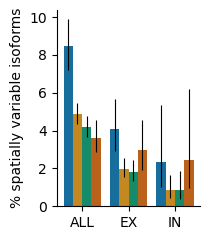

In [8]:
ci_low, ci_upp = proportion_confint((q_all < 0.05).sum(), (q_all.notna().sum()), method='wilson')

perc_sign_all = (100*(q_all < 0.05).sum()/q_all.notna().sum()).reset_index()
perc_sign_all['celltype'] = 'All'
ci_low, ci_upp = proportion_confint((q_all < 0.05).sum(), (q_all.notna().sum()), method='wilson')
perc_sign_all['ci_low'] = ci_low.values*100
perc_sign_all['ci_upp'] = ci_upp.values*100

perc_sign_exc = (100*(q_exc < 0.05).sum()/q_exc.notna().sum()).reset_index()
perc_sign_exc['celltype'] = 'Excite'
ci_low, ci_upp = proportion_confint((q_exc < 0.05).sum(), (q_exc.notna().sum()), method='wilson')
perc_sign_exc['ci_low'] = ci_low.values*100
perc_sign_exc['ci_upp'] = ci_upp.values*100


perc_sign_inh = (100*(q_inh < 0.05).sum()/q_inh.notna().sum()).reset_index()
perc_sign_inh['celltype'] = 'Inhib'
ci_low, ci_upp = proportion_confint((q_inh < 0.05).sum(), (q_inh.notna().sum()), method='wilson')
perc_sign_inh['ci_low'] = ci_low.values*100
perc_sign_inh['ci_upp'] = ci_upp.values*100

perc_sign_ct = pd.concat((perc_sign_all, perc_sign_exc, perc_sign_inh),axis=0)

lower_err = perc_sign_ct[0] - perc_sign_ct['ci_low']
upper_err = perc_sign_ct['ci_upp'] - perc_sign_ct[0]
yerr = np.array([lower_err.values, upper_err.values])

plt.figure(figsize=(2.2,2.5))
ax = sns.barplot(data=perc_sign_ct, x='celltype', y=0, hue='index',
                palette=palette)

x_loc = []

for i, bar in enumerate(ax.patches):
    x_loc.append(bar.get_x() + bar.get_width() / 2)

x_loc = np.array(x_loc)[:12]
plt.errorbar(x=np.sort(x_loc),
            y=perc_sign_ct[0],
            yerr=yerr,
            fmt='none',
            capsize=0,
            ecolor='black',
            elinewidth=0.8)
    
sns.despine()
plt.ylabel('% spatially variable isoforms')
plt.xlabel('')
plt.xticks(ax.get_xticks(), labels=['ALL','EX','IN'])
plt.tight_layout()
plt.legend('',frameon=False)
plt.show()

### Figure 4d - upset plot

In [9]:
q_all_filtered = q_all[(q_all < 0.05).any(axis=1)]
result = (q_all_filtered<0.05).groupby(['S1 (4K)', 'S1+S2 (AllExome)', 'S1 (AllExome)', 'S2 (AllExome)']).size()


/athena/tilgnerlab/scratch/lim4020/2022_08_15_PSIprediction/envs/SplIsoFind_016/lib/python3.9/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
/athena/tilgnerlab/scratch/lim4020/2022_08_15_PSIprediction/envs/SplIsoFind_016/lib/python3.9/site-packages/upsetplot/plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. Th

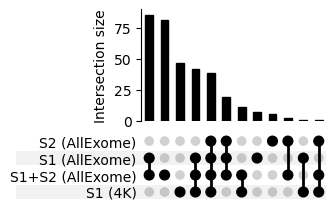

In [10]:
from upsetplot import UpSet
import matplotlib.pyplot as plt

up = UpSet(result, sort_by="cardinality", sort_categories_by="input", element_size=20)

fig = plt.figure()
up.plot(fig=fig)

fig.axes[2].remove()

for ax in fig.axes:
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontsize(10)

for ax in fig.axes:
    ax.grid(False)

fig.set_size_inches(4, 2.5)
plt.show()


### Figure 4e - celltype-constrained permutations

In [11]:
res_AE = pd.read_csv('stereoseq_data_analysis/comb_AE_ONT/isomatrix/res_comb/MoransI_sparse_pval_nperm10000_k50_ctconstrained.csv',
                    index_col=0)
res_AE.columns = ['moransI','Normal', 'CTconstrained',
                 'Num cells', 'Imbalance']
res_AE.head()

,moransI,Normal,CTconstrained,Num cells,Imbalance
variable,,,,,
ENSMUST00000032934.12,0.016918,0.0001,0.0001,28573,0.038813
ENSMUST00000169826.3,0.058611,0.0001,0.0001,18396,0.191237
ENSMUST00000223999.2,0.066164,0.0001,0.0001,18396,0.795282
ENSMUST00000164181.2,0.152456,0.0001,0.0001,13649,0.317020
ENSMUST00000218127.2,0.155179,0.0001,0.0001,13649,0.660708


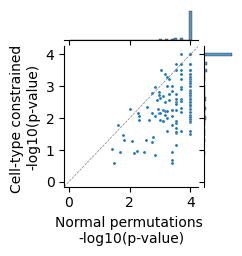

In [12]:
g = sns.jointplot(
    x=-np.log10(res_AE['Normal']),
    y=-np.log10(res_AE['CTconstrained']),
    marginal_kws={"binwidth": 0.1, "binrange": [0.05, 4.05]},
    height=2.5, s=5,
    ratio=4
)

# Add x = y line
lims = [
    np.min([g.ax_joint.get_xlim(), g.ax_joint.get_ylim()]),  # min of both axes
    np.max([g.ax_joint.get_xlim(), g.ax_joint.get_ylim()])   # max of both axes
]
g.ax_joint.plot(lims, lims, '--', color='gray', linewidth=0.5)  # diagonal line
g.ax_joint.set_xlim(lims)
g.ax_joint.set_ylim(lims)

# Set axis labels
g.set_axis_labels('Normal permutations \n-log10(p-value)',
                  'Cell-type constrained \n-log10(p-value)')
plt.show()

### Figure 4f - Snap25 example

In [13]:
dir_AE = 'stereoseq_data_analysis/comb_AE_ONT/isomatrix/'
dir_4k = 'stereoseq_data_analysis/S1_4K_ONT/isomatrix/'

x_AE, labels_AE, isoforms_AE = SplIsoFind.pp.load_sparse(input_dir = dir_AE)
x_4k, labels_4k, isoforms_4k = SplIsoFind.pp.load_sparse(input_dir = dir_4k)

# subset AE data for sample 1
labels_S1_AE = labels_AE[labels_AE['sample'] == 'S1']
x_S1_AE = x_AE[labels_AE['sample'] == 'S1']

# subset AE data for sample 2
labels_S2_AE = labels_AE[labels_AE['sample'] == 'S2']
x_S2_AE = x_AE[labels_AE['sample'] == 'S2']


In [14]:
im_reg_S1 = Image.open('tissue_staining/S1_ssDNA_regist.tif')
imarray_S1 = np.array(im_reg_S1)


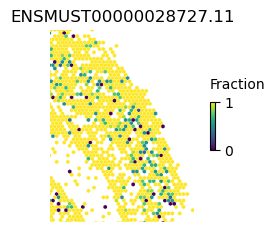

In [15]:
snap25_201 = 'ENSMUST00000028727.11'

xlim1=11000
xlim2=15500
ylim1=10500
ylim2=16500

SplIsoFind.pl.spatial_hexplot_sparse(x_S1_AE, 
                                     labels_S1_AE, 
                                     isoforms_AE,
                                     snap25_201, 
                                     imarray=imarray_S1,
                                     celltype='', 
                                     hexsize=200, fig_size= (4,2.5), 
                                     plot_lim=[xlim1, xlim2, ylim1, ylim2],
                                     alpha=1, cmap='viridis', 
                                     staining_max='white')

plt.show()

### Figure 4g - Snap25 layers

In [16]:
layers = ['L23','L4','L5','L6']

def layers_snap25(x_sparse, labels, isoforms, dataset):
    
    idx_var = np.where(isoforms['Transcript ID'] == snap25_201)[0]
    x_sparse_transcript = x_sparse[:,idx_var]
    idx_notNaN = x_sparse_transcript.tocoo().row
    labels_snap25 = labels.iloc[idx_notNaN]
    xx = pd.DataFrame(x_sparse_transcript[idx_notNaN].toarray(),
                      index = labels_snap25.index,
                      columns = isoforms.values[idx_var,1])
    
    tokeep = np.isin(labels_snap25['subregion'], layers)
    xx = xx[tokeep]
    labels_snap25 = labels_snap25[tokeep]

    xx_concat = pd.concat((labels_snap25['subregion'], xx), axis=1)
    xx_layers = xx_concat.groupby('subregion').mean()
    xx_layers['dataset'] = dataset

    return xx_layers
    

In [17]:
layers_snap25_S2 = layers_snap25(x_S2_AE,
                                 labels_S2_AE,
                                 isoforms_AE,
                                 'S2 (AE)')
layers_snap25_S1 = layers_snap25(x_S1_AE,
                                 labels_S1_AE,
                                 isoforms_AE,
                                 'S1 (AE)')
layers_snap25_4k = layers_snap25(x_4k,
                                 labels_4k,
                                 isoforms_4k,
                                 'S1 (4k)')
layers_snap25_comb = layers_snap25(x_AE,
                                 labels_AE,
                                 isoforms_AE,
                                 'comb')

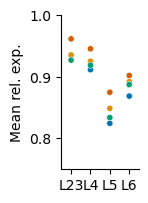

In [18]:
l_snap25 = pd.concat((layers_snap25_4k, layers_snap25_comb, layers_snap25_S1, layers_snap25_S2))

plt.figure(figsize=(1,2))
sns.scatterplot(data=l_snap25,
                x='subregion',
                y='ENSMUST00000028727.11',
               hue='dataset', palette='colorblind',
               hue_order=['S1 (4k)', 'comb', 'S1 (AE)', 'S2 (AE)'],
               s=20)
plt.ylim([0.75,1])
plt.xlim([-0.5,3.5])
plt.yticks([0.8,0.9,1.0])
plt.xlabel('')
plt.ylabel('Mean rel. exp.')
plt.legend('', frameon=False)
sns.despine()
plt.show()

### Figure 4h - significant isoforms per gene

In [19]:
# Map isoforms to genes
gene_transcript_mapping1 = pd.read_csv('stereoseq_data_analysis/S1_4K_ONT/isomatrix/genes_isoforms.csv',
                                     header=None)
gene_transcript_mapping2 = pd.read_csv('stereoseq_data_analysis/comb_AE_ONT/isomatrix/genes_isoforms.csv',
                                     header=None)
gene_transcript_mapping = pd.concat((gene_transcript_mapping1, gene_transcript_mapping2), axis=0)
gene_transcript_mapping = gene_transcript_mapping.drop_duplicates()
gene_transcript_mapping = gene_transcript_mapping.set_index(1)

gene_transcript_mapping.head()

,0
1,
ENSMUST00000038080.7,ENSMUSG00000000127.16
ENSMUST00000232945.2,ENSMUSG00000000127.16
ENSMUST00000000305.7,ENSMUSG00000000296.9
ENSMUST00000213528.2,ENSMUSG00000000296.9
ENSMUST00000214644.2,ENSMUSG00000000296.9


In [21]:
sign = q_all < 0.05
q_all_genes = gene_transcript_mapping.loc[q_all.index]
sign['Gene'] = q_all_genes[0]
sign = sign[(sign == True).any(axis=1)]

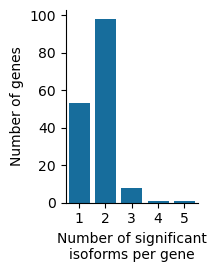

In [22]:
plt.figure(figsize=(1.7,2.5))
sns.barplot(data=pd.DataFrame(sign.groupby('Gene').sum().groupby('S1+S2 (AllExome)').size()[1:]).reset_index(),
           x='S1+S2 (AllExome)', y=0, color=sns.color_palette('colorblind')[0])
plt.ylabel('Number of genes')
plt.xlabel('Number of significant\nisoforms per gene')
sns.despine()
plt.show()

### Figure 4i - Arpp19 example

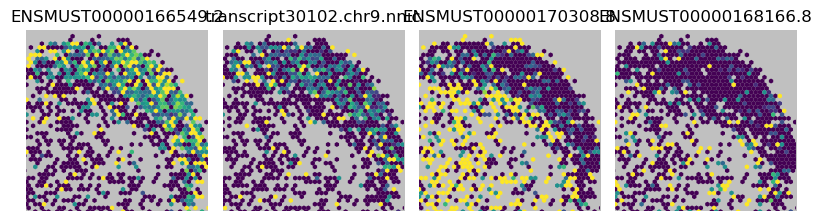

In [23]:
arpp19 = ['ENSMUST00000166549.2', 
          'transcript30102.chr9.nnic', 
          'ENSMUST00000170308.8',
          'ENSMUST00000168166.8']

xlim1=6500
xlim2=15000
ylim1=9000
ylim2=17500

fig, axs = plt.subplots(1,4, figsize=(8, 2.5))

for j,i in enumerate(arpp19):

    SplIsoFind.pl.spatial_hexplot_sparse(x_S1_AE, 
                                         labels_S1_AE, 
                                         isoforms_AE,
                                         i, 
                                         imarray=imarray_S1,
                                         celltype='', 
                                         hexsize=350, 
                                         plot_lim=[xlim1, xlim2, ylim1, ylim2],
                                         ax=axs[j],
                                         show_colorbar=False, 
                                         staining_min='silver',
                                         staining_max='silver',
                                         linewidths=0)
    
plt.tight_layout()
plt.show()


### Figure 4j - Rps24 example 

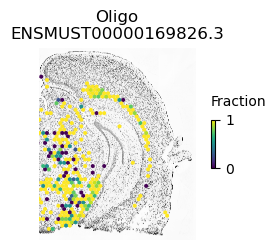

In [24]:
xlim1=6200
xlim2=17000
ylim1=4200
ylim2=17500

SplIsoFind.pl.spatial_hexplot_sparse(x_S1_AE, 
                                     labels_S1_AE, 
                                     isoforms_AE,
                                     'ENSMUST00000169826.3', 
                                     imarray=imarray_S1,
                                     celltype='Oligo', 
                                     hexsize=450, 
                                     plot_lim=[xlim1, xlim2, ylim1, ylim2], 
                                     fig_size=(4, 2.5),
                                     staining_max='black',
                                     linewidths=0)

plt.show()

### Figure 4k - comparison to predefined

In [25]:
### Res predefined
regions = ['All', 'cortex', 'HPC']

res_predefined_sig = pd.DataFrame(columns=['Gene','pvals','dPI','maxDeltaPI_ix1',
                                           'maxDeltaPI_ix2', 'FDR'])
res_predefined_tested = pd.DataFrame(columns=['Gene','pvals','dPI','maxDeltaPI_ix1',
                                              'maxDeltaPI_ix2', 'FDR'])

for r in regions:

    res_dir = f'stereoseq_data_analysis/comb_AE_ONT/predefined_analysis/res_scisorseqr/CellTypes_All_{r}'
    res_dir += '/TreeTraversal_Iso'

    for subdir in os.listdir(res_dir):

        res_dir2 = f'{res_dir}/{subdir}/'
        files = np.array(os.listdir(res_dir2))

        try:
            res_file = f"{res_dir2}/{files[np.char.endswith(files, 'results.csv')][0]}"

            x = pd.read_csv(res_file, sep='\t')
            sig = ((x['FDR'] <= 0.05) & (np.abs(x['dPI']) >= 0.1))
            x_sig = x[sig]            
            temp = np.array(subdir.split('_'))
            temp = temp[temp != 'ML']
            x_sig['reg1'] = temp[0]
            x_sig['reg2'] = temp[1]
            x['reg1'] = temp[0]
            x['reg2'] = temp[1]

            res_predefined_sig = pd.concat((res_predefined_sig,x_sig), axis=0)
            res_predefined_tested = pd.concat((res_predefined_tested,x), axis=0)
        except:
            pass


/scratch/lim4020_15099435/ipykernel_3121697/2908086389.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x_sig['reg1'] = temp[0]
/scratch/lim4020_15099435/ipykernel_3121697/2908086389.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x_sig['reg2'] = temp[1]
/scratch/lim4020_15099435/ipykernel_3121697/2908086389.py:32: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determini

In [26]:
res_moransI_tested = q_all[['S1+S2 (AllExome)']].dropna()
res_moransI_tested['Gene'] = gene_transcript_mapping.loc[q_all.index][0]

res_moransI_sig = res_moransI_tested[res_moransI_tested['S1+S2 (AllExome)'] < 0.05]


In [27]:
genes_tested_moransI = np.unique(res_moransI_tested['Gene'])
genes_tested_predefi = np.unique(res_predefined_tested['Gene'])
genes_tested_both = np.intersect1d(genes_tested_moransI, genes_tested_predefi)
genes_tested_moransI_only = np.setdiff1d(genes_tested_moransI, genes_tested_predefi)
genes_tested_predefi_only = np.setdiff1d(genes_tested_predefi, genes_tested_moransI)

len(genes_tested_both), len(genes_tested_moransI_only), len(genes_tested_predefi_only)


(2304, 0, 2989)

In [28]:
genes_sig_moransI = np.unique(res_moransI_sig['Gene'])
genes_sig_predefi = np.unique(res_predefined_sig['Gene'])

genes_sig_both = np.intersect1d(genes_sig_moransI, genes_sig_predefi)
genes_sig_moransI_only = np.setdiff1d(genes_sig_moransI, genes_sig_predefi)
genes_sig_predefi_only = np.setdiff1d(genes_sig_predefi, genes_sig_moransI)

len(genes_sig_both), len(genes_sig_moransI_only), len(genes_sig_predefi_only)

(146, 15, 242)

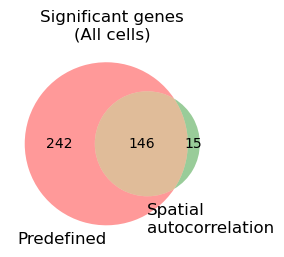

In [29]:
plt.figure(figsize=(3,2.5))
venn2(subsets=(len(genes_sig_predefi_only), 
               len(genes_sig_moransI_only), 
               len(genes_sig_both)), 
      set_labels=("Predefined", "Spatial\nautocorrelation"))
plt.title(f"Significant genes\n(All cells)")
plt.show()


### Figure 4l - Ighm example

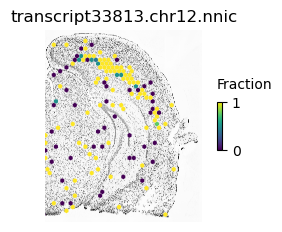

In [30]:
xlim1=6200
xlim2=17000
ylim1=4200
ylim2=17500

SplIsoFind.pl.spatial_hexplot_sparse(x_S1_AE, 
                                     labels_S1_AE, 
                                     isoforms_AE,
                                     'transcript33813.chr12.nnic', 
                                     imarray=imarray_S1,
                                     celltype='', 
                                     hexsize=500, 
                                     fig_size= (4, 2.5), 
                                     plot_lim=[xlim1, xlim2, ylim1, ylim2],
                                     staining_max='black')

plt.show()
